# Ontology Lab: Pizzas, Penguins, and a Reasoner

- This notebook builds an ontology from classes, individuals, properties,
  and axioms, then lets a description-logic reasoner classify and query it
- The pedagogical arc:
  - Ontology vs database schema vs taxonomy vs knowledge base
  - Subsumption and inconsistency on the Pizza ontology
  - Asserted hierarchy vs inferred hierarchy
  - Interactive axiom editing
  - Unsatisfiable concepts
  - Instance-level reasoning and the open world assumption
  - Expressiveness vs tractability in reasoner runtime
- The ontologies are built with `owlready2` and classified by HermiT, a
  description-logic reasoner called through `owlready2.sync_reasoner()`
- The Pizza ontology is rebuilt as a small subset inside
  `L03_04_ontology_reasoning_utils.py`, rather than downloaded, so that the
  cells need no network access and every axiom the reasoner uses is visible

## Imports

In [1]:
%load_ext autoreload
%autoreload 2

import logging

In [ ]:
!sympy==1.14.0

In [2]:
import helpers.hnotebook as hnotebook

import L03_04_ontology_reasoning_utils as utils

# Initialize notebook configuration and logging.
hnotebook.config_notebook()
_LOG = logging.getLogger(__name__)
utils.init_loggers(_LOG)

ModuleNotFoundError: No module named 'owlready2'

# Part 1: What an Ontology Adds to a Schema

## Cell 1.1: Building the university ontology

**Goal**:
- Construct the lecture's university ontology in code: classes, properties,
  and one cardinality axiom
- Distinguish an ontology from a plain database schema, a taxonomy, and a
  knowledge base
- _Class hierarchy_: the classes `Student`, `Professor`, `Course`, and
  `Department`, with the object properties `takesCourse`, `teachesCourse`,
  and `belongsToDepartment` drawn as dashed purple arrows
- _Comparison table_: ontology vs database schema vs taxonomy vs knowledge
  base, one row per property (has axioms, derives new facts, has instances)
- _Comments_: number of classes, properties, and axioms currently defined

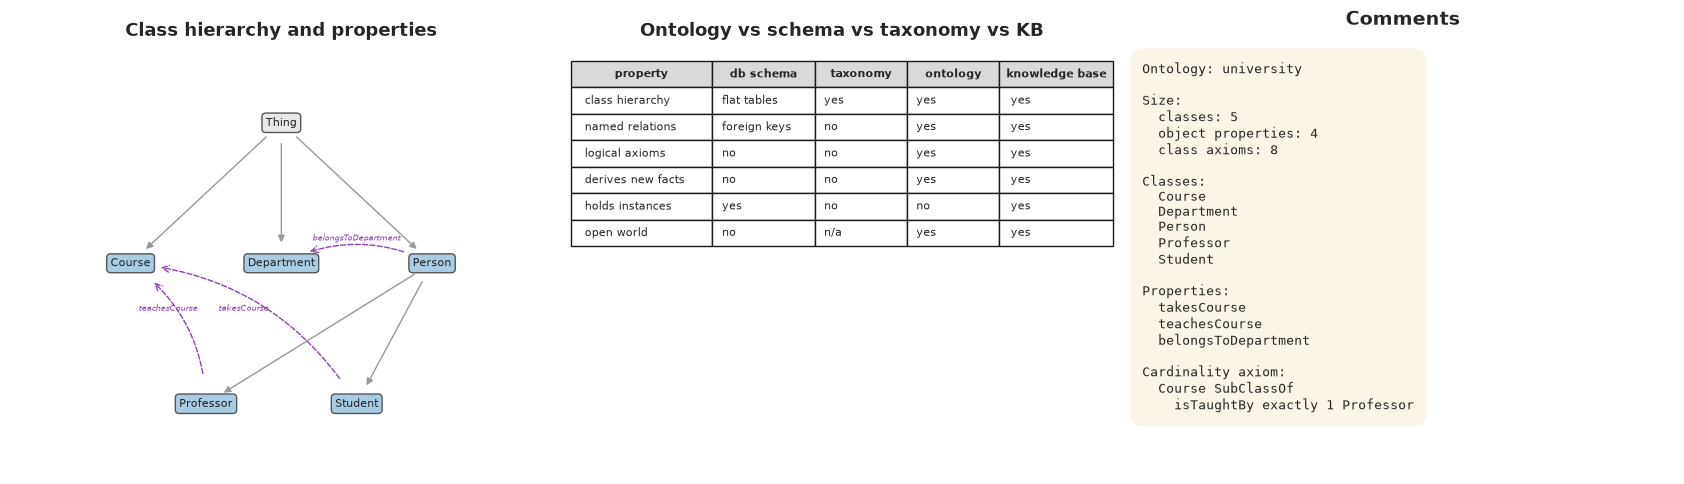

In [3]:
# Build the university ontology and compare it with the alternatives.
utils.cell1_1_university_ontology()

**Key observations**:
- A database schema constrains the shape of the data but cannot derive new
  facts: the ontology's axioms are what let a reasoner do exactly that
- A taxonomy is only the class hierarchy
  - The ontology adds properties and axioms on top of it
  - The left panel is a taxonomy as soon as the dashed property arrows are
    removed
- The cardinality axiom `Course SubClassOf isTaughtBy exactly 1 Professor`
  is a constraint a plain schema could enforce as well
  - Only the ontology can use it to draw new conclusions, for example that
    two professors asserted to teach one course must be the same individual
- Nothing has been inferred yet: this cell only asserts, and Part 2 starts
  asking the reasoner questions

# Part 2: Class-Level Reasoning on the Pizza Ontology

## The pizza axioms

- Every cell in this part reasons over the same subset of the Manchester
  Pizza ontology, the standard Protege teaching ontology
- The subset keeps what is needed to teach classification:
  - Three disjoint topping categories, with two named toppings each
  - Named pizzas listing the toppings they have, plus a closure axiom
    saying they have no other topping
  - `VegetarianPizza` defined by a universal restriction, so that
    membership in it is derived rather than asserted
  - `VegetarianAmericanPizza`, deliberately asserted to be both an
    `AmericanPizza` and a `VegetarianPizza`
- The axioms below are the ones the cells switch on and off; the rest of the
  ontology stays fixed

In [4]:
# Show the axioms the reasoner works with, in ASCII Manchester syntax.
utils.show_pizza_axioms()
# Outcome: 8 axioms, of which 5 turn out to be responsible for the
# inconsistency found in Cell 2.1.

,key,axiom
0,disjoint_toppings,"disjoint(CheeseTopping, MeatTopping, VegetableTopping)"
1,vegetarian_definition,VegetarianPizza EquivalentTo Pizza and (hasTopping only (CheeseTopping or VegetableTopping))
2,american_has_meat,AmericanPizza SubClassOf hasTopping some PeperoniSausageTopping
3,veg_american_is_american,VegetarianAmericanPizza SubClassOf AmericanPizza
4,veg_american_is_vegetarian,VegetarianAmericanPizza SubClassOf VegetarianPizza
5,closure_margherita,Margherita SubClassOf hasTopping only (MozzarellaTopping or TomatoTopping)
6,closure_mushroom,MushroomPizza SubClassOf hasTopping only (MozzarellaTopping or TomatoTopping or MushroomTopping)
7,interesting_pizza,InterestingPizza EquivalentTo Pizza and (hasTopping min 3 PizzaTopping)


## Cell 2.1: Subsumption and an inconsistent vegetarian

**Goal**:
- Run class-level reasoning on the Pizza ontology and read the verdict for
  one class at a time
- Ask the reasoner to classify a `VegetarianPizza` that lists a meat
  topping, and read its explanation
- _Class hierarchy_: the classified class tree, with the tested class
  highlighted in orange, or in red and struck through when the reasoner
  marks it unsatisfiable
- _Explanation panel_: for an unsatisfiable class, the axioms that cannot
  all hold at once; for a satisfiable one, the superclasses the reasoner
  proved, split into asserted and inferred
- _Comments_: class tested, reasoner verdict, reasoning time

**Parameters**:
- `pizza_class`: the class handed to the reasoner, including the one
  deliberately asserted to be both American and vegetarian

In [5]:
# Test one class at a time and read the reasoner's verdict.
utils.cell2_1_subsumption_and_inconsistency()

**Key observations**:
- Subsumption ("is `A` more general than `B`?") is answered structurally
  from the axioms, never by reading class names
  - `Margherita` is proved to be a `VegetarianPizza` although nobody
    asserted it, because its closure axiom leaves it no room for a meat
    topping
  - `AmericanPizza` is not, for exactly the same structural reason in
    reverse
- An inconsistency is a proof that no individual can satisfy every asserted
  axiom on that class at once
  - `VegetarianAmericanPizza` would need a topping that is a meat topping
    and, at the same time, a cheese or vegetable topping
- The explanation panel names the exact axioms responsible, not just the
  final "unsatisfiable" verdict
  - The five axioms it lists are found by dropping one axiom at a time and
    asking the reasoner again, which is the black-box way of computing a
    justification
  - Every one of the five is needed: drop any single one and the class
    becomes satisfiable again

- Try `InterestingPizza`: it has no asserted superclass at all, and the
  reasoner still places it under `Pizza`
- Try `MushroomPizza`: it is proved both vegetarian and interesting, so one
  class can gain more than one inferred parent

## Cell 2.2: Asserted hierarchy vs inferred hierarchy

**Goal**:
- Compare the class hierarchy as authored against the hierarchy after
  classification, on the same ontology
- _Diff graph_: the hierarchy with the asserted edges in blue and the newly
  inferred edges in green, switchable between the two views
- _Inferred edge table_: every subclass edge classification added, over all
  the classes of the ontology
- _Comments_: number of asserted edges, number of newly inferred edges

**Parameters**:
- `view`: `asserted only`, `inferred only`, or `both`

In [6]:
# Switch between the hierarchy as written and the hierarchy as classified.
utils.cell2_2_asserted_vs_inferred()

**Key observations**:
- Classification discovers subclass relationships the author never wrote
  explicitly, and the green edges are exactly those: 19 asserted edges
  become 23, of which 6 are new
- The gap between the asserted graph and the inferred graph is the value the
  reasoner adds
  - Every green edge is a fact a plain taxonomy would have needed a human to
    write down and to keep correct
- An ontology with no gap between the two graphs is one where the author
  already anticipated every consequence of their own axioms

- Try `inferred only`: the two defined classes `VegetarianPizza` and
  `InterestingPizza` collect all the new edges, because a defined class is
  exactly the kind of class whose members are worked out rather than listed
- Classification also drops 2 asserted edges as redundant: once
  `VegetarianPizza` and `InterestingPizza` are proved to sit under `Pizza`,
  their direct edge to `Thing` says nothing any more
- `VegetarianAmericanPizza` keeps only the two edges its author wrote: an
  unsatisfiable class is technically a subclass of every class at once,
  which is true but says nothing, so those edges are not drawn

## Cell 2.3: Interactive axiom editor

**Goal**:
- Add or remove one axiom, re-run the reasoner, and watch which edges the
  hierarchy gains or loses
- _Class hierarchy_: the same diagram as Cell 2.2, redrawn after each edit,
  with the inferred edges in green
- _Editable axioms_: which of the three editable axioms are currently in the
  ontology
- _Comments_: axiom just applied, number of hierarchy edges before and after

**Parameters**:
- `axiom_template`: the axiom to add if it is out of the ontology, or to
  remove if it is in
- `apply`: apply the edit and classify again

In [7]:
# Edit one axiom at a time and re-run the reasoner after each edit.
utils.cell2_3_axiom_editor()

**Key observations**:
- One removed axiom can cost many inferred edges at once
  - Removing `interesting_pizza` drops 3 of the 6 inferred edges, since the
    defined class leaves the middle of the hierarchy and both pizzas that
    were classified under it lose that parent
- Some axioms decide whether a class is satisfiable at all, which the
  diagram shows immediately
  - Removing `disjoint(CheeseTopping, MeatTopping, VegetableTopping)` makes
    `VegetarianAmericanPizza` satisfiable again, and the red strike-through
    disappears
  - The inferred edges elsewhere survive that removal, because the named
    toppings are declared pairwise distinct by an axiom the editor does not
    touch
- Removing `closure_margherita` costs exactly one edge
  - Without the closure axiom, nothing rules out a meat topping on a
    `Margherita`, so it can no longer be proved vegetarian
  - This is the open world assumption at the class level: not mentioning a
    meat topping is not the same as forbidding one
- Small, deliberate edits make the reasoner's behavior predictable instead
  of a black box

# Part 3: Satisfiability of a Concept

## Cell 3.1: Unsatisfiable concepts: the flying penguin

**Goal**:
- Define `FlyingPenguin` as `Penguin` and `FlyingThing`, and confirm the
  reasoner marks the concept unsatisfiable
- _Class hierarchy_: the bird hierarchy, with `FlyingPenguin` drawn in red
  and struck through when it is unsatisfiable
- _Explanation panel_: the two conflicting axioms, `Penguin`
  $\sqsubseteq \lnot Flying$ and `FlyingPenguin`
  $\equiv Penguin \sqcap Flying$
- _Comments_: whether `FlyingPenguin` is currently satisfiable

**Parameters**:
- `penguins_cannot_fly`: add or remove the "penguin cannot fly" axiom

In [8]:
# Toggle one axiom and watch a concept lose and regain its satisfiability.
utils.cell3_1_flying_penguin()

**Key observations**:
- Satisfiability is a per-class question, answerable before anyone tries to
  create an individual of that class
- An unsatisfiable class can never have members, no matter how the ontology
  is populated later
  - This is why the reasoner draws it as equivalent to $\bot$ rather than
    reporting an error: the ontology itself is still perfectly consistent
- Clearing `penguins_cannot_fly` flips `FlyingPenguin` back to satisfiable,
  which shows the axiom is exactly what caused the conflict
- The justification holds both axioms, not just the one that was toggled
  - Neither axiom is wrong on its own
  - An inconsistency is always a property of a set of axioms, never of a
    single one

# Part 4: Instance-Level Reasoning

## Cell 4.1: Realization, retrieval, and the open world assumption

**Goal**:
- Perform realization (the most specific class of an individual) and
  retrieval (the individuals satisfying a class), then ask a question about
  a fact that was never asserted
- The ontology adds `TeachingAssistant`, defined as a `Student` who teaches
  a `Course`, and four individuals nobody typed as one
- _Realization panel_: the class hierarchy with the classes of the selected
  individual highlighted, the most specific ones in purple
- _Retrieval table_: the individuals the query class retrieves, before and
  after reasoning
- _Open world query_: the same question answered under the closed and the
  open world assumption
- _Comments_: individual and class currently queried, and the result

**Parameters**:
- `individual`: the individual to realize
- `query_class`: the class used for retrieval and for the query
- `query_absent_fact`: ask whether the individual is in the query class

In [9]:
# Realize an individual, retrieve a class, then ask about an absent fact.
utils.cell4_1_realization_and_owa()

**Key observations**:
- Realization narrows an individual down to its most specific class, not
  just its asserted type
  - `alice` is asserted to be a `Student` and comes out a
    `TeachingAssistant`, because she is a student who teaches a course
- Retrieval lists every individual the reasoner can prove satisfies the
  class, including ones never explicitly typed that way
  - Querying `TeachingAssistant` before reasoning retrieves nobody, and
    after reasoning retrieves `alice`
- Under the open world assumption, an absent fact returns "unknown", never a
  hard "false": absence of information is not evidence of falsehood
  - `bob` is a student with no teaching assertion, so "is `bob` a teaching
    assistant?" answers unknown, where a database would answer no
  - `carol` is a student explicitly said to teach nothing, so the same
    question answers a provable false
  - The only difference between the two is that the world was closed around
    `carol` on purpose, by asserting what she does not do

# Part 5: Expressiveness vs Tractability

## Cell 5.1: Reasoner runtime as axioms grow

**Goal**:
- Measure how reasoner runtime grows as cardinality constraints and a
  property chain are added to the university ontology
- _Runtime curve_: reasoning time against the number of qualified number
  restrictions, one curve per property chain setting, with the current
  setting marked by a red star
- _Inference bar_: how many individuals the property chain adds to
  `WorksInTopUnit`, which is what the extra expressiveness buys
- _Comments_: current construct count, construct type, measured runtime

**Parameters**:
- `n`: number of cardinality constraints added, in $[0, 10]$
- `add_property_chain`: add the axiom `worksIn o partOf -> worksIn`

In [10]:
# Measure the reasoner as the ontology gains more expressive constructs.
utils.cell5_1_expressiveness_vs_tractability()

**Key observations**:
- Runtime grows once qualified number restrictions are introduced, compared
  to the plain class hierarchy of Cell 1.1
  - The curve is flat while the cardinalities are small and turns upward
    around $n = 6$, reaching three to four times the $n = 0$ time by
    $n = 10$
  - The growth is driven by the size of the cardinalities, not by the number
    of axioms: each new class asks the reasoner to build a model holding
    more distinct individuals than the previous one
  - This is the same reason a reasoner can be fast on a large taxonomy and
    slow on a small ontology
- This is the expressiveness vs tractability tension raised for
  propositional vs first-order logic, now visible in a description-logic
  reasoner
- Richer constructs buy more inferential power
  - The property chain multiplies the members of `WorksInTopUnit` by eight,
    from 5 to 40, since every member of a unit now counts as a member of
    every unit above it
  - At this ontology size the chain costs almost no time, so the two curves
    sit on top of each other: expressiveness is not automatically expensive,
    it is expensive when it forces the reasoner to build bigger models

- Try `n` $= 10$ with the chain on and off: the two measurements stay within
  noise of each other, while both are several times the measurement at
  $n = 0$
- The reasoner is called once per point and the results are cached, so the
  curve is measured on the first run of the cell and only redrawn afterwards

# Summary: The Mental Model

- An ontology is a taxonomy plus named properties plus logical axioms, and
  the axioms are what separate it from a database schema: they let a
  reasoner derive facts nobody wrote down
- Classification answers subsumption structurally, from the axioms alone, so
  a class can gain superclasses its author never asserted
- A closure axiom is what turns "has these toppings" into "has only these
  toppings", and without it the open world assumption leaves room for a
  topping nobody mentioned
- An unsatisfiable class is a proof that no individual could ever satisfy
  all of its axioms at once, and it leaves the rest of the ontology
  perfectly consistent
- An inconsistency belongs to a set of axioms, never to one axiom: a
  justification is the minimal set that cannot hold together, and every
  axiom in it is needed
- Realization finds the most specific class of an individual and retrieval
  finds the individuals of a class, and both routinely return answers that
  were never asserted
- Under the open world assumption a missing fact answers "unknown", and
  getting a "false" out of the reasoner takes an explicit axiom saying what
  is not the case
- Expressive constructs buy inferential power at a runtime cost that shows
  up when they force the reasoner to build larger models, which is the
  description-logic version of the expressiveness vs tractability trade-off